# DAS Event Examples

**Author:** Shihao Yuan  
**Contact:** yuanshihao88@gmail.com

This notebook collects **example events** observed in the Cook Strait DAS experiment and visualize them with **DASCore**.

Examples covered (as available in your dataset/time range):

- Airgun source signals 
- Earthquakes 
- Vessel/cruise passages 
- Traffic / other anthropogenic noise

You may need to **update local file paths** and time windows to match where your DAS files live.


In [ ]:
import os
import glob

import numpy as np
import pandas as pd

from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import dascore as dc
from dascore.units import Hz, m, s

from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import cartopy.feature as cfeature

# Use inline plotting for Jupyter (change to %matplotlib qt for interactive plots)
%matplotlib inline

print(f"DASCore version: {dc.__version__}")

DASCore version: 0.1.12


### Cable Geometry
Load the DAS cable route from a CSV file and plot it on a satellite basemap. Each point is coloured by its **optical distance** along the fibre.

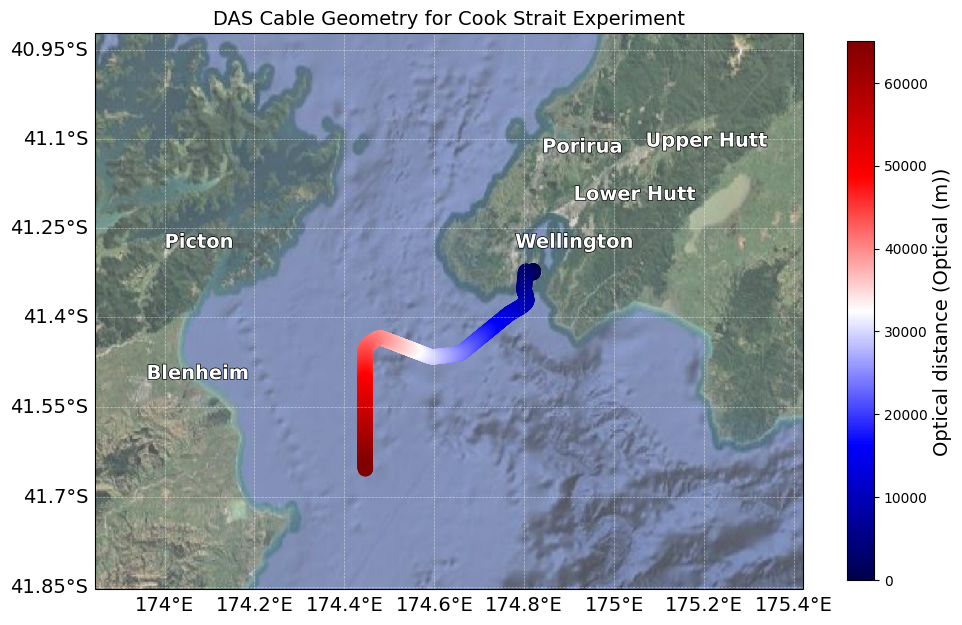

In [ ]:
# Path to the cable geometry file
geom_path = "/Volumes/ESNZ-DAS/Cook-Strait_experiment_2025/Sintela/Aqualink_10m.csv"
geom = pd.read_csv(geom_path)

# Helper function to find the column name
def _find_col(substr, required=True):
    matches = [c for c in geom.columns if substr in c.lower()]
    if not matches:
        if required:
            raise ValueError(
                f"Could not find a column containing '{substr}' in: {list(geom.columns)}"
            )
        return None
    return matches[0]

lat_col = _find_col("lat")     
lon_col = _find_col("lon")   

if any("optical" in c.lower() for c in geom.columns):
    dist_col = [c for c in geom.columns if "optical" in c.lower()][0]
    # Only keep from 0 to ~64970 m
    geom_sub = geom[geom[dist_col] <= 64970].copy()
    color_vals = geom_sub[dist_col]
    color_label = f"Optical distance ({dist_col})"
else:
    geom_sub = geom.copy()
    color_vals = geom_sub.index
    color_label = "Index along file"

preview_cols = [lat_col, lon_col]
if isinstance(color_vals, pd.Series):
    preview_cols.append(color_vals.name)

tiler = cimgt.GoogleTiles(style='satellite')

lon_min = geom_sub[lon_col].min() - 0.6
lon_max = geom_sub[lon_col].max() + 0.6
lat_min = geom_sub[lat_col].min() - 0.2
lat_max = geom_sub[lat_col].max() + 0.4

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.Mercator()})

zoom = 9 
ax.add_image(tiler, zoom, alpha=0.7)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

sc = ax.scatter(
    geom_sub[lon_col][::5],
    geom_sub[lat_col][::5],
    c=color_vals[::5],
    s=100,
    cmap="seismic",
    transform=ccrs.PlateCarree(),
)

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.7)
cbar.set_label(color_label,fontsize=14)

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="white", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {"size": 14, "color": "black"}
gl.ylabel_style = {"size": 14, "color": "black"}

places = {
    "Wellington":    (174.78, -41.29),
    "Lower Hutt":    (174.91, -41.21),
    "Upper Hutt":    (175.07, -41.12),
    "Porirua":       (174.84, -41.13),
    "Picton":        (174.00, -41.29),
    "Blenheim":      (173.96, -41.51),
    "Nelson":        (173.28, -41.27),
}

text_style = dict(
    fontsize=14, fontweight="bold", color="white",
    ha="left", va="bottom",
    path_effects=[
        __import__("matplotlib.patheffects", fromlist=["withStroke"]).withStroke(linewidth=1, foreground="black")
    ],
)

for name, (lon, lat) in places.items():
    if lon_min <= lon <= lon_max and lat_min <= lat <= lat_max:
        ax.text(lon, lat, name, transform=ccrs.PlateCarree(), **text_style)

ax.set_title("DAS Cable Geometry for Cook Strait Experiment",fontsize=14)

plt.tight_layout()

## Airgun source DAS recording

One-minute active-source recordings are stored under `Sintela_Active`. The next cell loads a single file, applies the same DASCore preprocessing as in the [preprocessing notebook](1-DAS_Preprocessing.ipynb) (decimate, detrend, taper, high-pass filter), and plots a waterfall of the airgun signal.

Loading: decimator_2025-10-12_13.03.30_UTC_075704.raw
Distance range: 0.0 – 64970.9 m
Time range    : 2025-10-12T13:03:30.854099639 – 2025-10-12T13:04:30.849099639


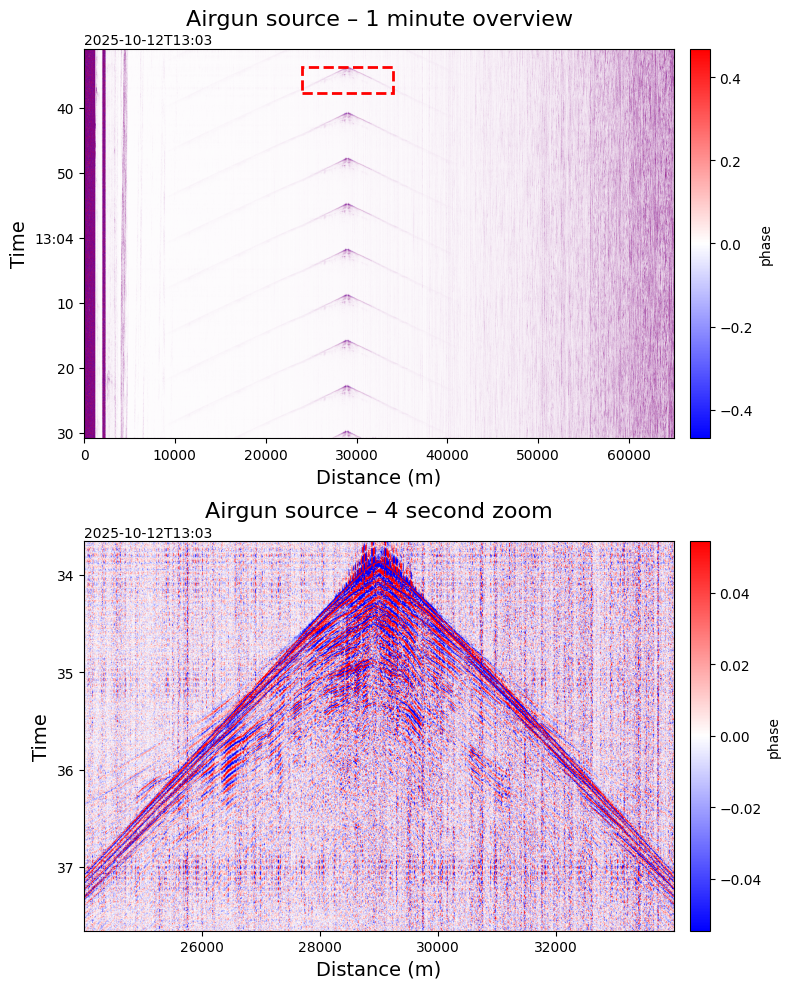

In [ ]:
# 1. Load one active-source (airgun) DAS recording
active_dir = "/Volumes/ESNZ-DAS/Cook-Strait_experiment_2025/Data/Sintela_Active"

raw_files = sorted(glob.glob(os.path.join(active_dir, "*.raw")))
if not raw_files:
    raise FileNotFoundError(f"No .raw files in {active_dir}")

data_path = raw_files[10]   # change index to pick another file
print(f"Loading: {os.path.basename(data_path)}")

spool = dc.spool(data_path)
patch = spool[0]

# 2. Preprocessing
patch_processed = (
    patch
    .set_units(distance="m", time="s")
    .decimate(time=5) # Decimate the data by a factor of 5
    .detrend("time") # Detrend the data
    .taper(time=0.001) # Apply a taper to the data
    .pass_filter(time=(5 * Hz, ...))   # high-pass at 10 Hz
)

dist_coord = patch_processed.get_coord("distance")
time_coord = patch_processed.get_coord("time")
print(f"Distance range: {dist_coord.min():.1f} – {dist_coord.max():.1f} m")
print(f"Time range    : {time_coord.min()} – {time_coord.max()}")

# 3. Plot
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Left panel – full window
patch_processed.viz.waterfall(ax=axes[0], scale=0.01)
axes[0].set_title("Airgun source – 1 minute overview",fontsize=16)
axes[0].set_ylabel("Time",fontsize=14)
axes[0].set_xlabel("Distance (m)",fontsize=14)

# Right panel – zoomed-in window
zoom_dist = (24000, 34000) # Define the zoom cable section
patch_zoom = patch_processed.select(distance=zoom_dist)
t1 = patch_zoom.get_coord("time").min() + np.timedelta64(2800, "ms") # Define the start time of the zoom window
t2 = t1 + np.timedelta64(4, "s") # Define the end time of the zoom window
patch_zoom = patch_zoom.select(time=(t1, t2)) 
patch_zoom.viz.waterfall(ax=axes[1], scale=0.01) 
axes[1].set_title("Airgun source – 4 second zoom",fontsize=16)
axes[1].set_ylabel("Time",fontsize=14)
axes[1].set_xlabel("Distance (m)",fontsize=14)

# Add a rectangle to the upper panel showing the zoom region.
rx0 = zoom_dist[0]
rx1 = zoom_dist[1] 
ry0 = t2
ry1 = t1
rect = Rectangle(
    (rx0, ry0), rx1 - rx0, ry1 - ry0,
    linewidth=2, edgecolor="red", facecolor="none", linestyle="--",
)
axes[0].add_patch(rect)

plt.tight_layout()

## Earthquake catalog

Query the **GeoNet FDSN catalog** for M ≥ 3.0 events within 1.5° of the DAS cable during a certain time window. Events are plotted on a New Zealand Mercator map with marker size scaled by magnitude and colour mapped to depth, alongside the approximate DAS cable extent.

3 Event(s) in Catalog:
2025-10-11T06:54:31.479487Z | -40.961, +175.066 | 3.13 MLv | manual
2025-10-11T01:39:14.654228Z | -40.810, +173.577 | 3.43 MLv | manual
2025-10-14T03:15:52.725669Z | -40.512, +175.043 | 3.26 MLv | manual


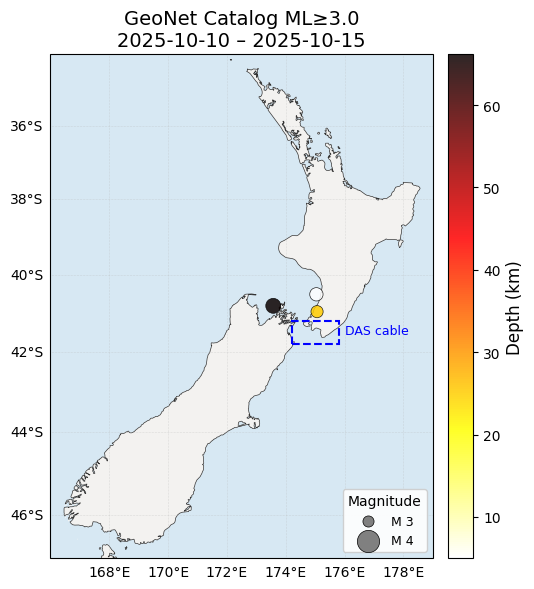

In [ ]:
geonet_client = Client("GEONET")

start = UTCDateTime("2025-10-10")
end = UTCDateTime("2025-10-15")

lon_center = (lon_min + lon_max) / 2
lat_center = (lat_min + lat_max) / 2
min_dist = 0.01 # degree
max_dist = 1.5 # degree

catalog = geonet_client.get_events(
    starttime=start,
    endtime=end,
    latitude=lat_center,
    longitude=lon_center,
    minradius=min_dist,
    maxradius=max_dist,
    minmagnitude=3.0
)
print(catalog)

evlons, evlats, evmags, evdepths = [], [], [], []
for ev in catalog:
    origin = ev.preferred_origin() or ev.origins[0]
    mag = ev.preferred_magnitude() or ev.magnitudes[0]
    evlons.append(origin.longitude)
    evlats.append(origin.latitude)
    evmags.append(mag.mag)
    evdepths.append(origin.depth / 1000.0 if origin.depth else 0)

proj = ccrs.Mercator(central_longitude=174)
pc = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": proj})
ax.set_extent([166, 179, -47, -34], crs=pc)

ax.add_feature(cfeature.OCEAN, facecolor="#d7e8f3")
ax.add_feature(cfeature.LAND, facecolor="#f3f2f0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="0.2")

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="0.7", alpha=0.7, linestyle=":")
gl.top_labels = False
gl.right_labels = False

sc = ax.scatter(
    evlons, evlats,
    s=[4 ** m for m in evmags],
    c=evdepths,
    cmap="hot_r",
    edgecolors="k", linewidths=0.5,
    alpha=0.85,
    transform=pc,
    zorder=5,
)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Depth (km)",fontsize=12)

cable_rect = Rectangle(
    (174.2, -41.8), 1.6, 0.6,
    linewidth=1.5, edgecolor="blue", facecolor="none", linestyle="--",
    transform=pc, zorder=6,
)
ax.add_patch(cable_rect)
ax.text(176.0, -41.45, "DAS Extent", transform=pc,
        fontsize=9, color="blue", va="center")

for mag_val in [3, 4]:
    ax.scatter([], [], s=4 ** mag_val, c="gray", edgecolors="k",
               linewidths=0.5, label=f"M {mag_val}", transform=pc)
ax.legend(loc="lower right", title="Magnitude", framealpha=0.9, fontsize=9, title_fontsize=10)

ax.set_title(f"GeoNet Catalog ML≥3.0\n{start.date} – {end.date}", fontsize=14)
plt.tight_layout()

## Earthquake DAS recordings

Load **continuous DAS files** with `dc.spool()`, find catalog events whose origin time falls inside the data window, then cut, process, and plot a waterfall for each matching event. Each event is windowed 10 s before to 70 s after the origin.

/var/folders/0f/qh8vgw8n4g570f0r6q17pdz00000gn/T/ipykernel_46723/3301446347.py:11: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  ot = np.datetime64(str(origin.time))


Events inside data window: 1
  2025-10-11T06:54:31.479487  M3.1 (MLv)  (-40.96, 175.07)  z=25.3 km


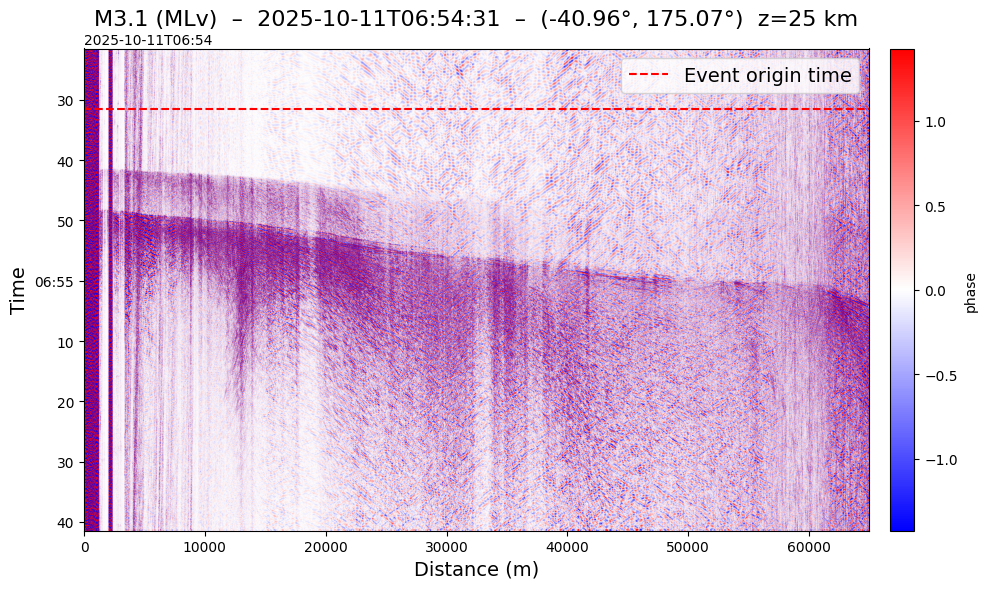

In [6]:
# 1. Load continuous data
continuous_dir = "/Volumes/ESNZ-DAS/Cook-Strait_experiment_2025/Data/Continuous"
spool_cont = dc.spool(continuous_dir).update()
data_start = spool_cont[0].get_coord("time").min()
data_end   = spool_cont[-1].get_coord("time").max()

# 2. Find catalog events inside the data window
events_in_window = []
for ev in catalog:
    origin = ev.preferred_origin() or ev.origins[0]
    ot = np.datetime64(str(origin.time))
    if data_start <= ot <= data_end:
        mag = ev.preferred_magnitude() or ev.magnitudes[0]
        events_in_window.append({
            "time": ot,
            "lat": origin.latitude,
            "lon": origin.longitude,
            "depth_km": origin.depth / 1000.0 if origin.depth else 0,
            "mag": mag.mag,
            "mag_type": mag.magnitude_type,
        })

print(f"Events inside data window: {len(events_in_window)}")
for e in events_in_window:
    print(f"  {e['time']}  M{e['mag']:.1f} ({e['mag_type']})  "
          f"({e['lat']:.2f}, {e['lon']:.2f})  z={e['depth_km']:.1f} km")

# 3. Preprocess & plot each event 
pre_event_s  = 10    # seconds before origin to include
post_event_s = 70   # seconds after origin
fmin, fmax   = 0.1 * Hz, 50 * Hz  # bandpass for local events

if not events_in_window:
    print("No catalog events overlap the continuous data window.")
    print("Try expanding the dataset or lowering minmagnitude.")
else:
    for e in events_in_window:
        t_origin = e["time"]
        t0 = t_origin - np.timedelta64(pre_event_s, "s")
        t1 = t_origin + np.timedelta64(post_event_s, "s")

        # Select, merge and process the data
        patch_eq = (
                    spool_cont
                    .select(time=(t0, t1))
                    .chunk(time=None)
                )
    
        patch_eq_processed = (
                    patch_eq[0]
                    .decimate(time=10)
                    .set_units(distance="m", time="s")
                    .detrend("time")
                    .taper(time=0.001)
                    .pass_filter(time=(fmin, ...))
                    
                )

        fig, ax = plt.subplots(figsize=(10, 6))
        patch_eq_processed.viz.waterfall(ax=ax, scale=0.008)
        ax.set_title(
            f"M{e['mag']:.1f} ({e['mag_type']})  –  "
            f"{str(e['time'])[:19]}  –  "
            f"({e['lat']:.2f}°, {e['lon']:.2f}°)  z={e['depth_km']:.0f} km",
            fontsize=16,
        )
        ax.axhline(t_origin, color="r", ls="--", lw=1.5, label="Event origin time")
        ax.legend(loc="upper right",fontsize=14)
        ax.set_ylabel("Time",fontsize=14)
        ax.set_xlabel("Distance (m)",fontsize=14)
        plt.tight_layout()
        plt.show()